# 📊 Day 15 — Machine Learning Intro
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ What is Machine Learning  
2️⃣ Types of Machine Learning  
3️⃣ Key Terminology  
4️⃣ The ML Workflow  
5️⃣ Loading & Preparing the Data  
6️⃣ Splitting Data — Train & Test  
7️⃣ First ML Model — Linear Regression  
8️⃣ Evaluating the Model  
9️⃣ First Classifier — Logistic Regression  
🔟 When to Use What  

---
## 1️⃣ What is Machine Learning?

Machine Learning is the process of **teaching a computer to learn from data** without explicitly programming every rule.

Instead of writing:
- `if price > 50 and points > 90 → premium wine`

You show the model thousands of examples and it **learns the pattern itself**.

> **Simple definition:** Machine Learning = Finding patterns in data and using them to make predictions.

---
## 2️⃣ Types of Machine Learning

| Type | Description | Example |
|------|-------------|---------|
| Supervised Learning | Learn from labeled data | Predict wine price from points |
| Unsupervised Learning | Find patterns in unlabeled data | Group wines by similarity |
| Reinforcement Learning | Learn by reward and punishment | Game-playing AI |

**Today we focus on Supervised Learning** — the most common type in real projects.

---
## 3️⃣ Key Terminology

| Term | Meaning | Example |
|------|---------|--------|
| Feature (X) | Input variable used to predict | Wine points |
| Target (y) | Output variable we want to predict | Wine price |
| Model | The algorithm that learns patterns | Linear Regression |
| Training | Feeding data to the model to learn | Fit model on 80% of data |
| Testing | Evaluating model on unseen data | Test on 20% of data |
| Prediction | Model's output for new data | Predicted price for a new wine |
| Overfitting | Model memorizes training data | Works on train, fails on test |
| Underfitting | Model is too simple to learn | Poor performance on both |

---
## 4️⃣ The ML Workflow

Every ML project follows the same steps:

```
1. Collect Data
2. Clean & Prepare Data
3. Split into Train & Test
4. Choose a Model
5. Train the Model
6. Evaluate the Model
7. Improve & Repeat
```

---
## 5️⃣ Loading & Preparing the Data

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Winemag dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [3]:
# Keep only relevant columns and drop missing values
df_ml = df[['points', 'price']].dropna()

print("Shape:", df_ml.shape)
df_ml.head()

Shape: (120975, 2)


,points,price
1,87,15.0
2,87,14.0
3,87,13.0
4,87,65.0
5,87,15.0


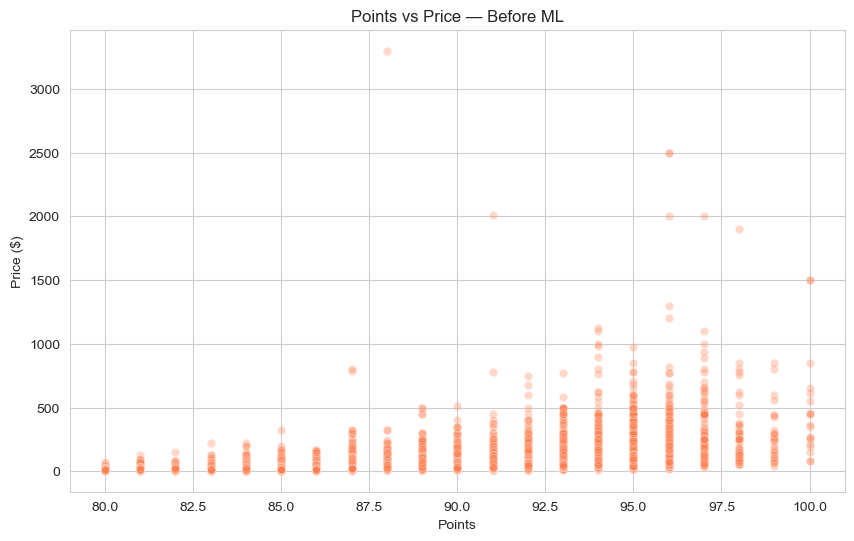

In [4]:
# Quick look at the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ml, x='points', y='price', alpha=0.3, color='coral')
plt.title("Points vs Price — Before ML")
plt.xlabel("Points")
plt.ylabel("Price ($)")
plt.show()

---
## 6️⃣ Splitting Data — Train & Test

We split data so the model learns on one part and gets tested on unseen data.

In [5]:
# Define features (X) and target (y)
X = df_ml[['points']]   # Feature — 2D array required
y = df_ml['price']       # Target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (120975, 1)
Target shape: (120975,)


In [6]:
# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (96780, 1)
Testing size: (24195, 1)


#### 💡 Tip

| Split | Purpose |
|-------|---------|
| Training set (80%) | Model learns from this |
| Test set (20%) | We evaluate model on this — model never sees it during training |
| `random_state=42` | Ensures same split every time you run the code |

---
## 7️⃣ First ML Model — Linear Regression

Linear Regression predicts a **numerical value** by finding the best straight line through the data.

In [7]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficient (slope):", round(model.coef_[0], 2))
print("Intercept:", round(model.intercept_, 2))

Model trained successfully!
Coefficient (slope): 5.55
Intercept: -455.69


In [8]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Show first 5 predictions vs actual values
comparison = pd.DataFrame({'Actual Price': y_test.values[:5], 'Predicted Price': y_pred[:5].round(2)})
comparison

,Actual Price,Predicted Price
0,26.0,27.46
1,40.0,55.22
2,30.0,44.12
3,24.0,21.90
4,16.0,16.35


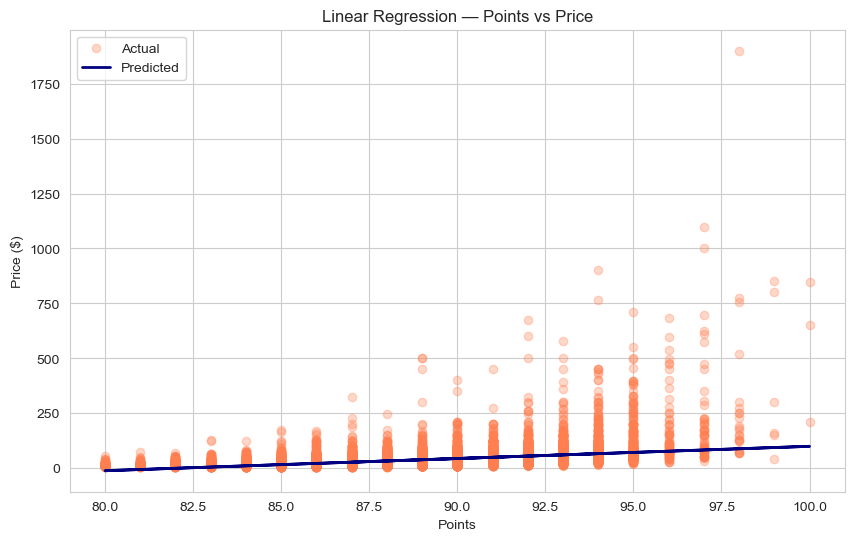

In [9]:
# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='coral', alpha=0.3, label='Actual')
plt.plot(X_test, y_pred, color='navy', linewidth=2, label='Predicted')
plt.title("Linear Regression — Points vs Price")
plt.xlabel("Points")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

---
## 8️⃣ Evaluating the Model

We use metrics to measure how well the model is performing.

In [10]:
# Regression evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error):  {mae:.2f}")
print(f"MSE  (Mean Squared Error):   {mse:.2f}")
print(f"RMSE (Root Mean Sq Error):   {rmse:.2f}")
print(f"R²   (R-Squared Score):      {r2:.4f}")

MAE  (Mean Absolute Error):  17.22
MSE  (Mean Squared Error):   1343.32
RMSE (Root Mean Sq Error):   36.65
R²   (R-Squared Score):      0.1904


#### What just happened? 🤔

| Metric | Meaning | Ideal Value |
|--------|---------|-------------|
| MAE | Average error in dollars | As low as possible |
| MSE | Penalizes large errors more | As low as possible |
| RMSE | Same unit as target (dollars) | As low as possible |
| R² | % of variance explained by model | Closer to 1.0 is better |

---
## 9️⃣ First Classifier — Logistic Regression

Logistic Regression predicts a **category** (yes/no, 0/1).  
Here we predict whether a wine is **premium** (points ≥ 90) or not.

In [11]:
# Create a binary target — 1 = premium (90+ points), 0 = regular
df_ml['is_premium'] = (df_ml['points'] >= 90).astype(int)

print("Premium wines:", df_ml['is_premium'].sum())
print("Regular wines:", (df_ml['is_premium'] == 0).sum())

Premium wines: 45391
Regular wines: 75584


In [12]:
# Features and target for classification
X_cls = df_ml[['price']]
y_cls = df_ml['is_premium']

# Train test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

In [13]:
# Train Logistic Regression
clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)

# Predict
y_pred_c = clf.predict(X_test_c)

# Evaluate
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_c) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Accuracy: 74.46 %

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.90      0.82     15230
           1       0.74      0.48      0.58      8965

    accuracy                           0.74     24195
   macro avg       0.74      0.69      0.70     24195
weighted avg       0.74      0.74      0.73     24195



---
## 🔟 When to Use What

| Algorithm | Use When | Target Type |
|-----------|----------|-------------|
| Linear Regression | Predict a number | Continuous (price, salary) |
| Logistic Regression | Predict a category | Binary (yes/no, 0/1) |
| Decision Tree | Complex rules | Both |
| Random Forest | High accuracy needed | Both |
| K-Means | Group similar data | No target (unsupervised) |

---
## 🔑 Key Takeaways

→ Machine Learning = teaching computers to find patterns in data  
→ Always split data into train and test before building any model  
→ `random_state=42` ensures reproducible results every time  
→ Linear Regression predicts numbers — Logistic Regression predicts categories  
→ R² score tells you how much of the variation the model explains  
→ A model that only works on training data is overfitting — always test on unseen data  
→ The ML workflow is always the same — data → split → train → evaluate → improve

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 15 of 100 — Keep Learning, Keep Building 🚀*